In [1]:
import re
import os
import pandas as pd
import numpy as np
pd.set_option("display.max_colwidth", None)  # Show full column width
pd.set_option("display.max_rows", 100)       # Show up to 100 rows
pd.set_option("display.max_columns", 10)     # Show up to 10 columns
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import unicodedata
from collections import Counter
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import random
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
import networkx as nx

In [2]:
%matplotlib inline

In [3]:
# Define text cleaning function
def clean_text(text):
    # Normalize unicode characters
    text = unicodedata.normalize("NFKC", text)

    # Standardize quotes and dashes
    text = text.replace("“", '"').replace("”", '"')
    text = text.replace("‘", "'").replace("’", "'")
    text = text.replace("–", "-").replace("—", "-")

    # Remove tabs, non-breaking spaces, form feeds
    text = text.replace("\t", " ")
    text = text.replace("\xa0", " ")
    text = text.replace("\f", " ")

    # Collapse all whitespace into single spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

# Path to the folder containing your .txt files
corpus_path = "/Users/floorstikkelbroeck/Desktop/MA_CompLit_Thesis/corpus_thesis"

# Optional: list of specific filenames to include (without .txt)
# Leave empty to include all files
selected_files = []  # Example: ["frankenstein", "pride_and_prejudice"]

# Dictionary to hold text contents
texts = {}

# Loop through and clean all selected .txt files
for filename in os.listdir(corpus_path):
    if filename.endswith(".txt"):
        name = os.path.splitext(filename)[0]  # Remove '.txt'
        if not selected_files or name in selected_files:
            file_path = os.path.join(corpus_path, filename)
            with open(file_path, 'r', encoding='utf-8') as f:
                raw_text = f.read()
                cleaned_text = clean_text(raw_text)
                texts[name] = cleaned_text


In [4]:
#for testing take one or two text and print a few characters
selected_files = ["Atwood_OryxandCrake_2003", "Egan_Diaspora_1997"]
print(texts["Egan_Diaspora_1997_BETA"][:100])  # prints first 500 characters

# for a full run take all of the texts


Part One Yatima surveyed the Doppler-shifted stars around the polis, following the frozen, concentri


In [5]:
def plot_word_counts(texts, sort_by="alphabetical", color_by_beta=True):
    """
    Count total words per text and plot as horizontal bar chart.

    Args:
        texts (dict): {title: text}
        sort_by (str): 'alphabetical' or 'count'
        color_by_beta (bool): Highlight BETA/MBETA texts in orange
    """

    # Step 1: Count words
    word_counts = {}
    for title, text in texts.items():
        words = re.findall(r"\b\w+\b", text)
        word_counts[title] = len(words)

    # Step 2: Sort
    if sort_by == "alphabetical":
        items = sorted(word_counts.items())
    elif sort_by == "count":
        items = sorted(word_counts.items(), key=lambda x: x[1])
    else:
        raise ValueError("sort_by must be 'alphabetical' or 'count'")

    titles, counts = zip(*items)

    # Step 3: Colors
    if color_by_beta:
        colors = ["darkorange" if "BETA" in title or "MBETA" in title else "steelblue" for title in titles]
    else:
        colors = "gray"

    # Step 4: Plot
    plt.figure(figsize=(12, 0.3 * len(titles)))
    plt.barh(titles, counts, color=colors)
    plt.xlabel("Word Count")
    plt.title(f"Word Count per Text ({sort_by.capitalize()} Order)")
    plt.vlines(50000, -1, len(titles), colors='gray', linestyles='dashed', label='50,000 words')
    plt.vlines(100000, -1, len(titles), colors='gray', linestyles='dashed', label='100,000 words')
    plt.vlines(150000, -1, len(titles), colors='gray', linestyles='dashed', label='150,000 words')
    plt.vlines(200000, -1, len(titles), colors='gray', linestyles='dashed', label='200,000 words')
    plt.tight_layout()
    plt.show()
    return word_counts


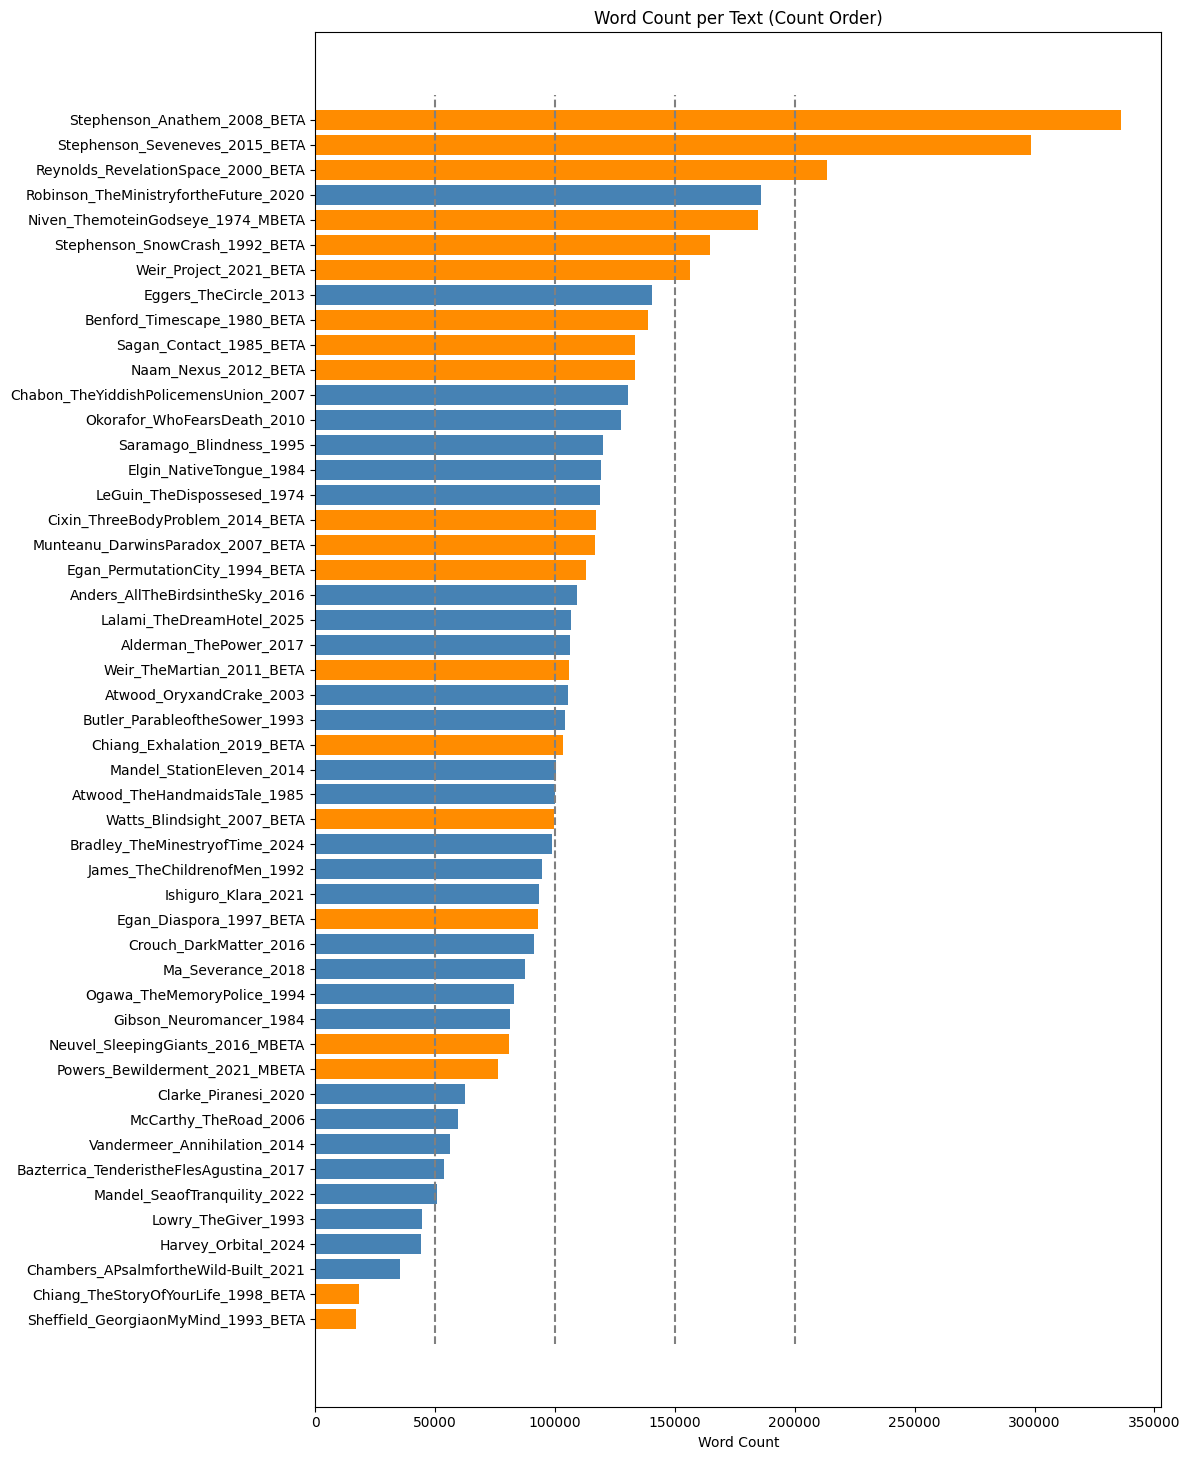

In [6]:
# Alphabetical order
# plot_word_counts(texts, sort_by="alphabetical")

# By increasing word count
word_counts = plot_word_counts(texts, sort_by="count")


In [7]:
def exclude_titles(texts, exclude_list):
    """
    Return a new dict with titles excluded.

    Args:
        texts (dict): Original {title: text} dictionary
        exclude_list (list): List of titles to exclude (exact match)

    Returns:
        dict: Filtered version
    """
    return {title: text for title, text in texts.items() if title not in exclude_list}

exclude_list = [
    "Stephenson_Anathem_2008_BETA",
    "Stephenson_Seveneves_2015_BETA",
    "Reynolds_RevelationSpace_2000_BETA",
    "Lowry_TheGiver_1993",
    "Harvey_Orbital_2024",
    "Chambers_APsalmfortheWild-Built_2021",
    "Chiang_TheStoryOfYourLife_1998_BETA",
    "Sheffield_GeorgiaonMyMindandOtherPlaces_1993_BETA"
]

# texts = exclude_titles(texts, exclude_list)


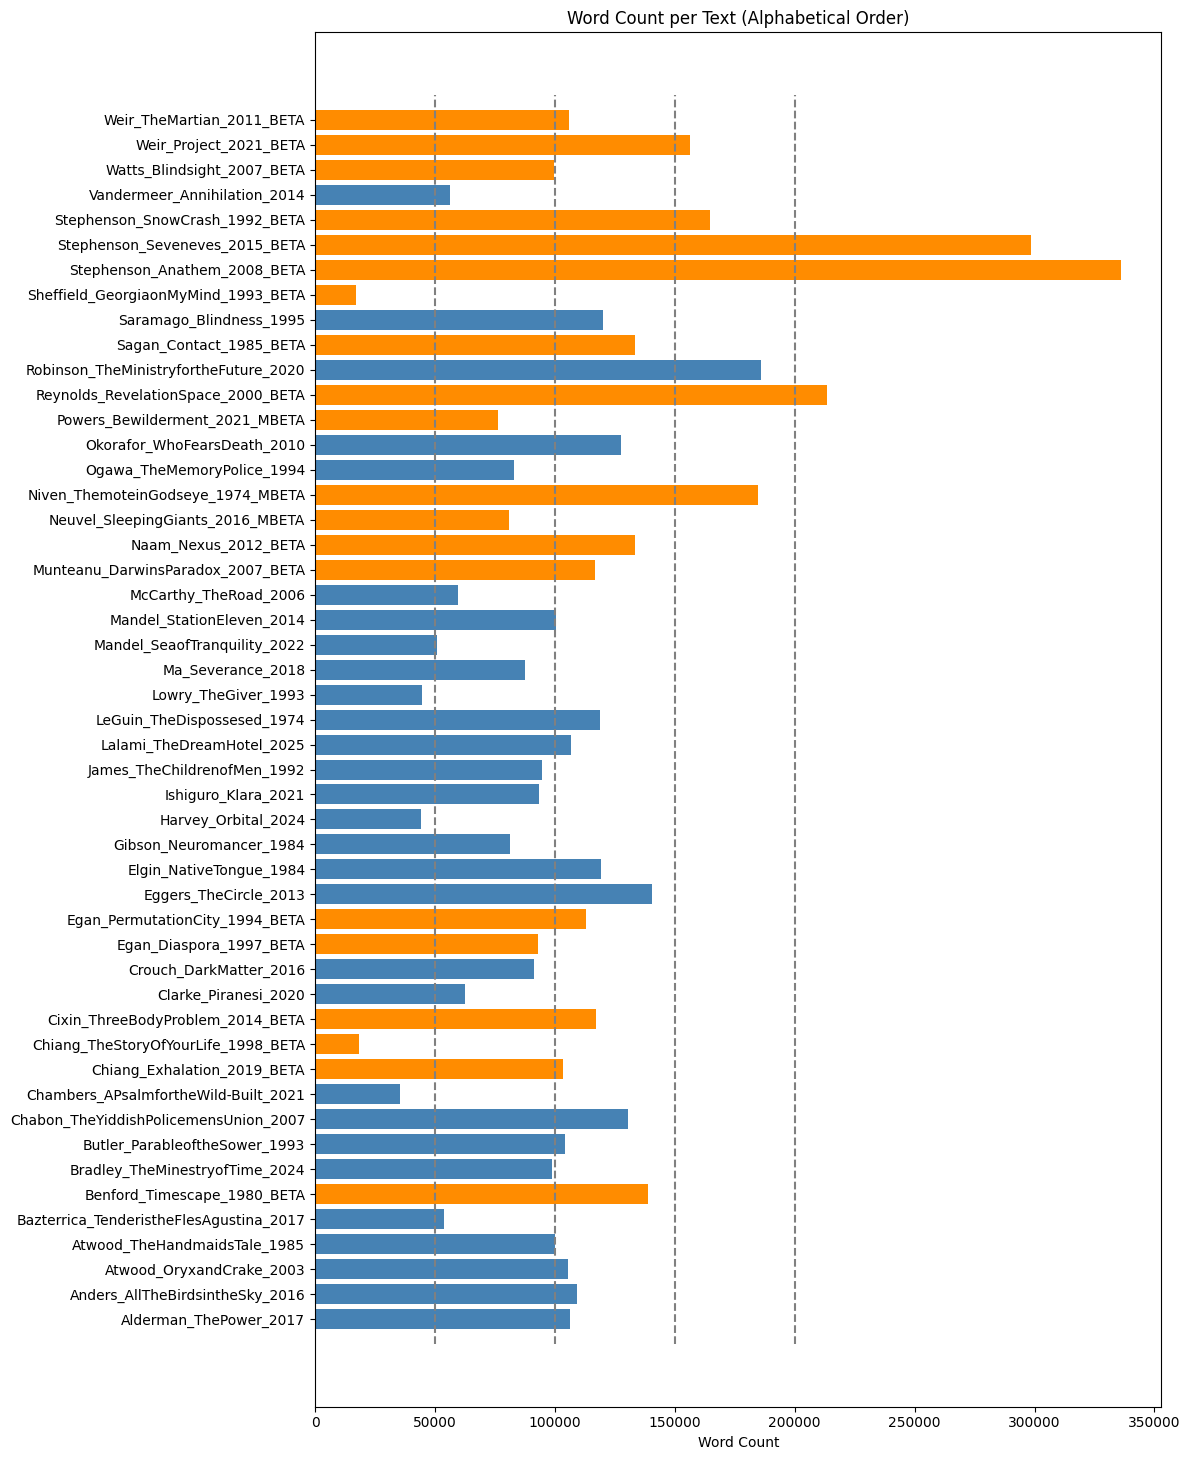

{'Sheffield_GeorgiaonMyMind_1993_BETA': 17244,
 'Powers_Bewilderment_2021_MBETA': 76172,
 'McCarthy_TheRoad_2006': 59683,
 'Crouch_DarkMatter_2016': 91438,
 'Chambers_APsalmfortheWild-Built_2021': 35466,
 'Neuvel_SleepingGiants_2016_MBETA': 80778,
 'Benford_Timescape_1980_BETA': 139014,
 'Elgin_NativeTongue_1984': 119144,
 'Watts_Blindsight_2007_BETA': 99539,
 'Egan_Diaspora_1997_BETA': 93055,
 'Mandel_StationEleven_2014': 100610,
 'Atwood_TheHandmaidsTale_1985': 99909,
 'Robinson_TheMinistryfortheFuture_2020': 186101,
 'Eggers_TheCircle_2013': 140485,
 'Clarke_Piranesi_2020': 62309,
 'Gibson_Neuromancer_1984': 81471,
 'Weir_TheMartian_2011_BETA': 105864,
 'Butler_ParableoftheSower_1993': 104302,
 'Ishiguro_Klara_2021': 93413,
 'Lowry_TheGiver_1993': 44669,
 'Lalami_TheDreamHotel_2025': 106853,
 'Okorafor_WhoFearsDeath_2010': 127400,
 'Atwood_OryxandCrake_2003': 105532,
 'Reynolds_RevelationSpace_2000_BETA': 213470,
 'Alderman_ThePower_2017': 106495,
 'Saramago_Blindness_1995': 120060,

In [8]:
plot_word_counts(texts, sort_by="alphabetical")

# 1. Concordance KWIC

In [9]:
def concordance_kwic(text, keyword, width=30, ignore_case=True, max_results=None, align=True, highlight=True):
    clean_text = re.sub(r'\s+', ' ', text)
    words = clean_text.split()

    # Match keyword + optional possessive or punctuation endings
    pattern = re.compile(rf"^{re.escape(keyword)}[’'`s]*[.,!?;:]*$", re.IGNORECASE if ignore_case else 0)

    results = []

    for i, word in enumerate(words):
        if pattern.match(word):
            left = " ".join(words[max(i - width, 0):i])
            right = " ".join(words[i + 1:i + 1 + width])

            if align:
                left = left.rjust(width * 10)
                right = right.ljust(width * 10)

            results.append((left, word, right))

            if max_results and len(results) >= max_results:
                break

    df = pd.DataFrame(results, columns=["Left", "Keyword", "Right"])

    if highlight:
        def highlight_kwic(val):
            return 'color: white; background-color: royalblue; font-weight: bold'

        styled_df = df.style.applymap(highlight_kwic, subset=["Keyword"])
        return styled_df
    else:
        return df


In [10]:
df = concordance_kwic(texts["Niven_ThemoteinGodseye_1974_MBETA"], "people", width=10)


/var/folders/vv/2nq91_0d0lsfm6gcskyz__r40000gn/T/ipykernel_55038/1205179122.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df.style.applymap(highlight_kwic, subset=["Keyword"])


In [11]:
word_counts

{'Sheffield_GeorgiaonMyMind_1993_BETA': 17244,
 'Powers_Bewilderment_2021_MBETA': 76172,
 'McCarthy_TheRoad_2006': 59683,
 'Crouch_DarkMatter_2016': 91438,
 'Chambers_APsalmfortheWild-Built_2021': 35466,
 'Neuvel_SleepingGiants_2016_MBETA': 80778,
 'Benford_Timescape_1980_BETA': 139014,
 'Elgin_NativeTongue_1984': 119144,
 'Watts_Blindsight_2007_BETA': 99539,
 'Egan_Diaspora_1997_BETA': 93055,
 'Mandel_StationEleven_2014': 100610,
 'Atwood_TheHandmaidsTale_1985': 99909,
 'Robinson_TheMinistryfortheFuture_2020': 186101,
 'Eggers_TheCircle_2013': 140485,
 'Clarke_Piranesi_2020': 62309,
 'Gibson_Neuromancer_1984': 81471,
 'Weir_TheMartian_2011_BETA': 105864,
 'Butler_ParableoftheSower_1993': 104302,
 'Ishiguro_Klara_2021': 93413,
 'Lowry_TheGiver_1993': 44669,
 'Lalami_TheDreamHotel_2025': 106853,
 'Okorafor_WhoFearsDeath_2010': 127400,
 'Atwood_OryxandCrake_2003': 105532,
 'Reynolds_RevelationSpace_2000_BETA': 213470,
 'Alderman_ThePower_2017': 106495,
 'Saramago_Blindness_1995': 120060,

# 2. Concordance Plot

In [12]:
def concordance_plot(
    texts, keyword, word_counts,
    ignore_case=True, height_per_text=0.5,
    sort_by="alphabetical", per_n_words=10000
):
    import matplotlib.pyplot as plt
    import re

    hit_counts = {}
    norm_freq = {}
    text_data = {}

    for title, text in texts.items():
        clean_text = re.sub(r"\s+", " ", text)
        words = clean_text.split()

        # Prefer your precomputed counts; fallback to split-length if missing
        n_words = word_counts.get(title, len(words))

        hits = []
        for index, word in enumerate(words):
            check = word.lower() if ignore_case else word
            if re.fullmatch(rf"{re.escape(keyword.lower())}[''`s]*[.,!?;:]*", check):
                hits.append(index / len(words))  # keep positions based on actual token list

        hit_counts[title] = len(hits)
        norm_freq[title] = (len(hits) / n_words) * per_n_words if n_words else 0.0
        text_data[title] = (words, hits, n_words)

    # Sorting
    if sort_by == "count":
        sorted_titles = sorted(hit_counts, key=hit_counts.get, reverse=True)
    elif sort_by == "rate":
        sorted_titles = sorted(norm_freq, key=norm_freq.get, reverse=True)
    else:
        sorted_titles = sorted(texts.keys())

    n_texts = len(texts)
    fig, axes = plt.subplots(n_texts, 1, figsize=(10, height_per_text * n_texts), sharex=True)
    if n_texts == 1:
        axes = [axes]

    for i, title in enumerate(sorted_titles):
        ax = axes[i]
        words, hits, n_words = text_data[title]

        is_beta = "BETA" in title or "MBETA" in title
        line_color = "darkorange" if is_beta else "steelblue"
        title_color = line_color

        ax.vlines(hits, ymin=0, ymax=1, color=line_color)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_xlim(0, 1)

        if i == n_texts - 1:
            ax.set_xlabel("Position in text")
        else:
            ax.set_xticklabels([])

        rate = norm_freq[title]
        ax.text(
            1.01, 0.5,
            f"{title} ({len(hits)}, {rate:.2f}/{per_n_words})",
            transform=ax.transAxes, fontsize=9, ha="left", va="center", color=title_color
        )

        ax.axvline(0.5, color="gray", linestyle="--", alpha=0.3)

    plt.tight_layout(h_pad=0.1)
    plt.show()


# 3. Word Frequencies

In [13]:
def word_frequencies_per_text(texts, ignore_case=True):
    """
    Calculate word frequencies for each text individually.

    Args:
        texts (dict): {filename: text}
        ignore_case (bool): Whether to lowercase words

    Returns:
        dict: {filename: Counter({word: count, ...})}
    """
    freqs = {}

    for name, text in texts.items():
        words = re.sub(r'\s+', ' ', text).split()
        if ignore_case:
            words = [w.lower() for w in words]
        freqs[name] = Counter(words)

    return freqs

In [14]:
per_text_freqs = word_frequencies_per_text(texts)
per_text_freqs["Egan_Diaspora_1997_BETA"].most_common(100)

[('the', 6333),
 ('of', 2651),
 ('to', 2426),
 ('a', 2137),
 ('and', 1705),
 ('in', 1171),
 ('was', 1096),
 ('it', 850),
 ('but', 717),
 ('had', 696),
 ('that', 661),
 ('as', 617),
 ('with', 597),
 ('for', 554),
 ('they', 517),
 ('from', 456),
 ('yatima', 433),
 ('on', 432),
 ('he', 432),
 ('have', 430),
 ('be', 413),
 ('would', 403),
 ('were', 401),
 ('at', 399),
 ('you', 389),
 ('into', 383),
 ('could', 376),
 ('their', 335),
 ('no', 332),
 ('if', 314),
 ('an', 308),
 ('by', 307),
 ('his', 307),
 ('or', 296),
 ('one', 295),
 ('ve', 293),
 ('all', 289),
 ('this', 271),
 ('been', 266),
 ('out', 250),
 ('there', 238),
 ('vis', 236),
 ('not', 235),
 ('them', 235),
 ('more', 227),
 ('than', 217),
 ('paolo', 213),
 ('like', 212),
 ('its', 195),
 ('orlando', 193),
 ('we', 192),
 ('then', 191),
 ('just', 189),
 ('so', 184),
 ('up', 181),
 ('i', 181),
 ('inoshiro', 180),
 ('what', 179),
 ('some', 163),
 ('only', 160),
 ('even', 160),
 ('about', 160),
 ('is', 156),
 ('through', 149),
 ('every'

In [15]:
def top_n_words_corpus(freqs_per_text, n=100):
    """
    Compute the top N most frequent words across the full corpus.

    Args:
        freqs_per_text (dict): Output of word_frequencies_per_text
        n (int): Number of top words to return

    Returns:
        list of str: top-N word list
    """
    total_freqs = Counter()
    for counter in freqs_per_text.values():
        total_freqs.update(counter)

    return [word for word, _ in total_freqs.most_common(n)]


In [16]:
def frequency_matrix(freqs_per_text, top_words):
    """
    Build a DataFrame where rows = texts, columns = top words over whole corpus.

    Args:
        freqs_per_text (dict): Output from word_frequencies_per_text
        top_words (list of str): List of words to include

    Returns:
        pd.DataFrame: word frequency table
    """
    data = []

    for name in sorted(freqs_per_text):
        counter = freqs_per_text[name]
        row = [counter.get(word, 0) for word in top_words]
        data.append(row)

    return pd.DataFrame(data, index=sorted(freqs_per_text), columns=top_words)


In [17]:
per_text_freqs = word_frequencies_per_text(texts)
top_words = top_n_words_corpus(per_text_freqs, n=2000)
freq_df = frequency_matrix(per_text_freqs, top_words)


## 3.1 Concordance shizzle

Can i take my concordance plot, or rather the rate I calculate with that concordance plot, and test which novel has the highest rate for a semantic cluster?

In [18]:
import re

def keyword_hit_positions(words, keyword, ignore_case=True):
    hits = []
    kw = keyword.lower() if ignore_case else keyword
    for i, word in enumerate(words):
        check = word.lower() if ignore_case else word
        if re.fullmatch(rf"{re.escape(kw)}['’`s]*[.,!?;:]*", check):
            hits.append(i)
    return hits

def cluster_rates(texts, cluster, word_counts, ignore_case=True, per_n_words=10000):
    rates = {}
    raw_hits = {}

    for title, text in texts.items():
        words = re.sub(r"\s+", " ", text).split()
        n_words = word_counts.get(title, len(words))

        total_hits = 0
        for kw in cluster:
            total_hits += len(keyword_hit_positions(words, kw, ignore_case=ignore_case))

        raw_hits[title] = total_hits
        rates[title] = (total_hits / n_words) * per_n_words if n_words else 0.0
        rates[title] = round(rates[title], 2)

    # Calculate spread statistics
    rate_values = list(rates.values())
    mean_rate = np.mean(rate_values)
    std_rate = np.std(rate_values)
    median_rate = np.median(rate_values)
    
    spread_stats = {
        'mean': round(mean_rate, 2),
        'std': round(std_rate, 2),
        'median': round(median_rate, 2),
        'min': round(min(rate_values), 2),
        'max': round(max(rate_values), 2)
    }

    return rates, raw_hits, spread_stats


In [ ]:
cluster = ["religion", "faith", "belief", "church", "temple", "prayer", "god", "gods"]
# # cluster = [
#     "science", "scientific", "scientist", "research", "researcher",
#     "experiment", "experimental", "hypothesis", "theory", "model",
#     "data", "evidence", "analysis", "method", "measure", "measurement",
#     "observation", "observe", "test", "result", "conclusion",
#     "laboratory", "lab", "study", "peer", "review", "publish", "publication"
# ]
# cluster = ["love", "romance", "affection", "passion", "heart", "desire", "relationship", "marriage", "intimacy", "emotion", 
#            "feelings", "lover", "beloved", "adore", "devotion", "yearning", "longing", "infatuation", "attachment", "caring", 
#            "compassion", "tenderness", "fondness", "sweetheart", "darling", "honey", "dear", "sweetie", "soulmate", "partner"]

rates, raw_hits, spread_stats = cluster_rates(texts, cluster, word_counts, per_n_words=10000)

# top_title = max(rates, key=rates.get)
# top_rate = rates[top_title]
# top_hits = hits[top_title]
# top_title, top_rate, top_hits

ranking = sorted(rates.items(), key=lambda x: x[1], reverse=True)
ranking[:10]

[('Sagan_Contact_1985_BETA', 20.52),
 ('Butler_ParableoftheSower_1993', 19.56),
 ('Chambers_APsalmfortheWild-Built_2021', 18.05),
 ('James_TheChildrenofMen_1992', 13.44),
 ('Alderman_ThePower_2017', 11.27),
 ('Stephenson_SnowCrash_1992_BETA', 8.32),
 ('Atwood_TheHandmaidsTale_1985', 8.11),
 ('Chabon_TheYiddishPolicemensUnion_2007', 7.82),
 ('McCarthy_TheRoad_2006', 6.87),
 ('Niven_ThemoteinGodseye_1974_MBETA', 6.87)]

# 4. Clustering Analysis

In [20]:
def plot_clustering_dendrogram(freq_df, method='ward'):
    from scipy.cluster.hierarchy import linkage, dendrogram
    import matplotlib.pyplot as plt

    # Get labels
    labels = freq_df.index.tolist()

    # Create linkage matrix
    Z = linkage(freq_df.values, method=method)

    # Assign colors based on BETA status
    def leaf_color_func(label_index):
        label = labels[label_index]
        return 'darkorange' if 'BETA' in label or 'MBETA' in label else 'steelblue'

    # Plot dendrogram
    plt.figure(figsize=(10, 0.35 * len(labels)))
    dendrogram(
        Z,
        labels=labels,
        orientation='left',
        distance_sort=True,
        leaf_font_size=9,
        leaf_rotation=0,
        link_color_func=lambda k: 'gray',  # keep branches neutral
        color_threshold=0,  # prevents auto coloring of clusters
        leaf_label_func=lambda x: labels[x],  # ensure correct label order
        above_threshold_color='gray',
    )

    # Color labels manually
    ax = plt.gca()
    xlbls = ax.get_ymajorticklabels()
    for lbl in xlbls:
        text = lbl.get_text()
        lbl.set_color('darkorange' if 'BETA' in text or 'MBETA' in text else 'steelblue')

    plt.title(f"Hierarchical Clustering (method = '{method}')")
    plt.xlabel("Distance")
    plt.ylabel("Text")
    plt.tight_layout()
    plt.show()


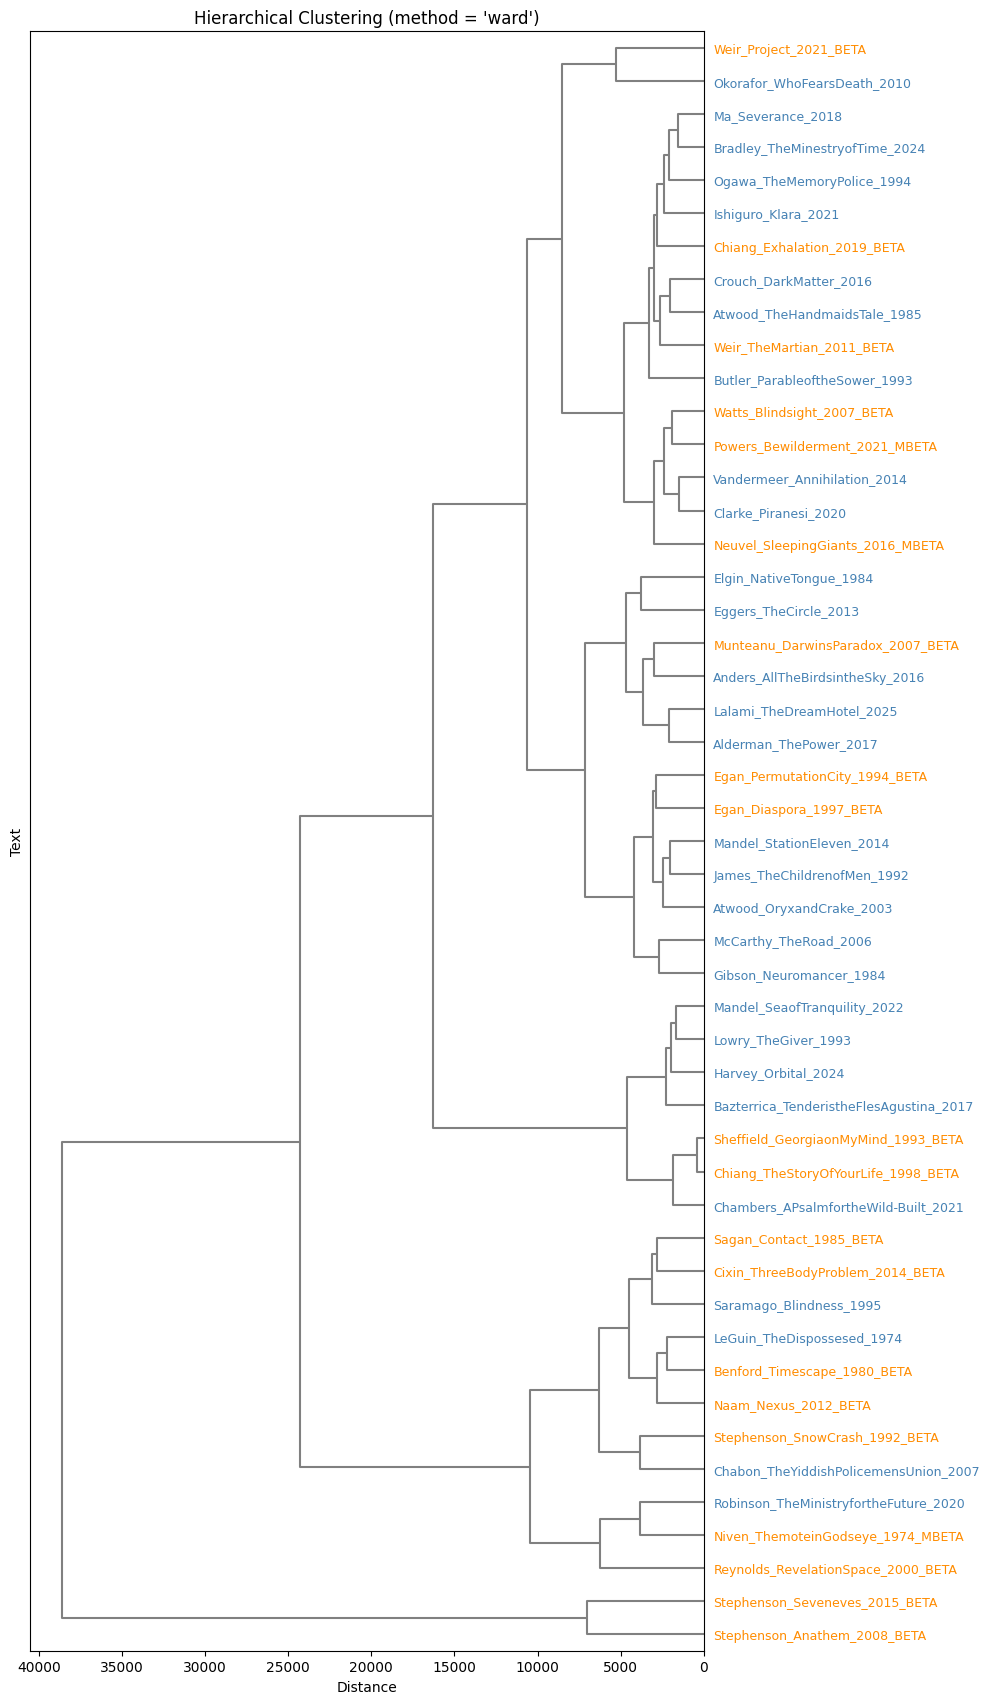

In [21]:
plot_clustering_dendrogram(freq_df, method='ward')

# 5. PCA 

In [22]:
#Step 1: normalise the freq_df for the 100 most common words in the dataset
# TODO: Loadings inladen! (op basis van 100 woorden)

def zscore_normalize(df):
    return (df - df.mean()) / df.std()

#Step 2: PCA using Numpy
def run_pca_numpy(df, n_components=2):
    # df should be the scaled + filtered one (no NaNs)
    cov_matrix = np.cov(df.T)

    eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
    sorted_idx = np.argsort(eig_vals)[::-1]
    eig_vals = eig_vals[sorted_idx]
    eig_vecs = eig_vecs[:, sorted_idx]

    components = eig_vecs[:, :n_components]

    # Project onto components
    pca_coords = df @ components
    pca_coords.columns = [f"PC{i+1}" for i in range(n_components)]

    return pca_coords, eig_vals[:n_components], cov_matrix


def plot_pca(pca_df, annotate=True, save_path=None):
    import plotly.express as px

    # Color BETA texts differently
    colors = ["BETA/MBETA" if ("BETA" in name or "MBETA" in name) else "Other"
              for name in pca_df.index]

    # Short labels for hover
    short_labels = []
    for label in pca_df.index:
        short_label = label
        if "_" in label:
            parts = label.replace("_MBETA", "").replace("_BETA", "").split("_")
            if len(parts) >= 3:
                author = parts[0][:3]
                title = parts[1][:3]
                year = parts[-1][-2:]
                short_label = author + title + year
        short_labels.append(short_label)

    df_plot = pca_df.copy()
    df_plot["Group"] = colors
    df_plot["Label"] = short_labels
    df_plot["Full"] = pca_df.index

    fig = px.scatter(
        df_plot,
        x="PC1",
        y="PC2",
        color="Group",
        color_discrete_map={"BETA/MBETA": "darkorange", "Other": "steelblue"},
        hover_name="Full",
        hover_data={"Label": True, "PC1": True, "PC2": True},
        title="PCA of Word Frequencies (BETA Highlighted)"
    )

    if annotate:
        fig.update_traces(text=df_plot["Label"], textposition="top right")

    # Make the plot more square
    fig.update_layout(width=1200, height=700)

    if save_path:
        fig.write_image(save_path, scale=2)

    fig.show()



In [23]:
freq_df_scaled = zscore_normalize(freq_df)
pca_df, explained, matrix = run_pca_numpy(freq_df_scaled)
plot_pca(pca_df, annotate=True, save_path="first_PCA_cleaned.png")

In [24]:
freq_df

,the,to,of,a,and,...,recent,"hours,",holds,problems,"year,"
Alderman_ThePower_2017,5546,2646,1940,2446,2671,...,5,0,30,1,3
Anders_AllTheBirdsintheSky_2016,4547,2822,2004,2678,3027,...,1,4,0,7,1
Atwood_OryxandCrake_2003,5118,2198,2130,2686,2273,...,2,2,7,2,2
Atwood_TheHandmaidsTale_1985,5159,2261,2095,2120,1799,...,1,1,8,5,4
Bazterrica_TenderistheFlesAgustina_2017,3311,1585,878,1226,1516,...,0,2,8,3,1
Benford_Timescape_1980_BETA,7782,2957,2939,3431,2791,...,15,6,0,16,8
Bradley_TheMinestryofTime_2024,4668,2223,1990,2412,2109,...,2,1,1,2,9
Butler_ParableoftheSower_1993,3526,2950,1813,1914,2945,...,0,1,3,2,8
Chabon_TheYiddishPolicemensUnion_2007,7941,2950,4170,4086,3250,...,11,6,29,0,6
Chambers_APsalmfortheWild-Built_2021,1879,766,691,806,799,...,1,4,1,1,0


In [25]:
def filter_outliers(pca_df, z_thresh=1.5, verbose=True):
    # Compute absolute z-scores
    z_scores = ((pca_df - pca_df.mean()) / pca_df.std()).abs()
    
    # Keep only rows where ALL z-scores < threshold
    keep_mask = (z_scores < z_thresh).all(axis=1)
    
    # Print excluded (outlier) texts
    if verbose:
        excluded = pca_df[~keep_mask]
        print(f"{len(excluded)} texts excluded as outliers (z_thresh = {z_thresh}):")
        for name in excluded.index:
            print(f" - {name}")

    return pca_df[keep_mask]


pca_df_zoom = filter_outliers(pca_df, z_thresh=1.5)
plot_pca(pca_df_zoom, annotate=True, save_path="pca_zoom_beta_highlighted.png")


7 texts excluded as outliers (z_thresh = 1.5):
 - Chabon_TheYiddishPolicemensUnion_2007
 - Okorafor_WhoFearsDeath_2010
 - Reynolds_RevelationSpace_2000_BETA
 - Sheffield_GeorgiaonMyMind_1993_BETA
 - Stephenson_Anathem_2008_BETA
 - Stephenson_Seveneves_2015_BETA
 - Stephenson_SnowCrash_1992_BETA


# 6. Zeta analysis

In [26]:
group_stem = {name: text for name, text in texts.items() if "BETA" in name or "MBETA" in name}
group_nonstem = {name: text for name, text in texts.items() if "BETA" not in name and "MBETA" not in name}

In [27]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

def count_group_freqs(texts):
    total_counter = Counter()
    for text in texts.values():
        tokens = tokenize(text)
        total_counter.update(set(tokens))  # Set to count per-document presence
    return total_counter

freqs_a = count_group_freqs(group_stem)
freqs_b = count_group_freqs(group_nonstem)

In [28]:
def compute_zeta_scores(freqs_a, freqs_b, size_a, size_b):
    all_words = set(freqs_a) | set(freqs_b)
    zeta_data = []

    for word in all_words:
        a_count = freqs_a.get(word, 0)
        b_count = freqs_b.get(word, 0)

        a_rate = a_count / size_a
        b_rate = b_count / size_b

        zeta_score = a_rate - b_rate  # Difference in rates of appearance
        zeta_data.append((word, zeta_score, a_rate, b_rate))

    return pd.DataFrame(zeta_data, columns=["Word", "Zeta", "Stem_Rate", "NonStem_Rate"]).sort_values(by="Zeta", ascending=False)


In [ ]:
zeta_df = compute_zeta_scores(freqs_a, freqs_b, size_a=len(group_stem), size_b=len(group_nonstem))



In [59]:
zeta_head = zeta_df.head(10) #see what is most prominent in stem group 
zeta_tail = zeta_df.tail(10)  # see what is least prominent in stem group

# Export full dataframe (easy for Google Sheets/Docs workflow)
csv_path = os.path.join(os.path.expanduser("~/Desktop"), "zeta_table.csv")
tsv_path = os.path.join(os.path.expanduser("~/Desktop"), "zeta_table.tsv")

zeta_head.to_csv(tsv_path, index=False)            # standard CSV
# zeta_df.to_csv(tsv_path, sep="\t", index=False)  # tab-separated (paste-friendly)
# zeta_tail.to_csv(tsv_path, sep="\t", index=False)  # tab-separated (paste-friendly)

print("Saved:", csv_path)
print("Saved:", tsv_path)



Saved: /Users/floorstikkelbroeck/Desktop/zeta_table.csv
Saved: /Users/floorstikkelbroeck/Desktop/zeta_table.tsv


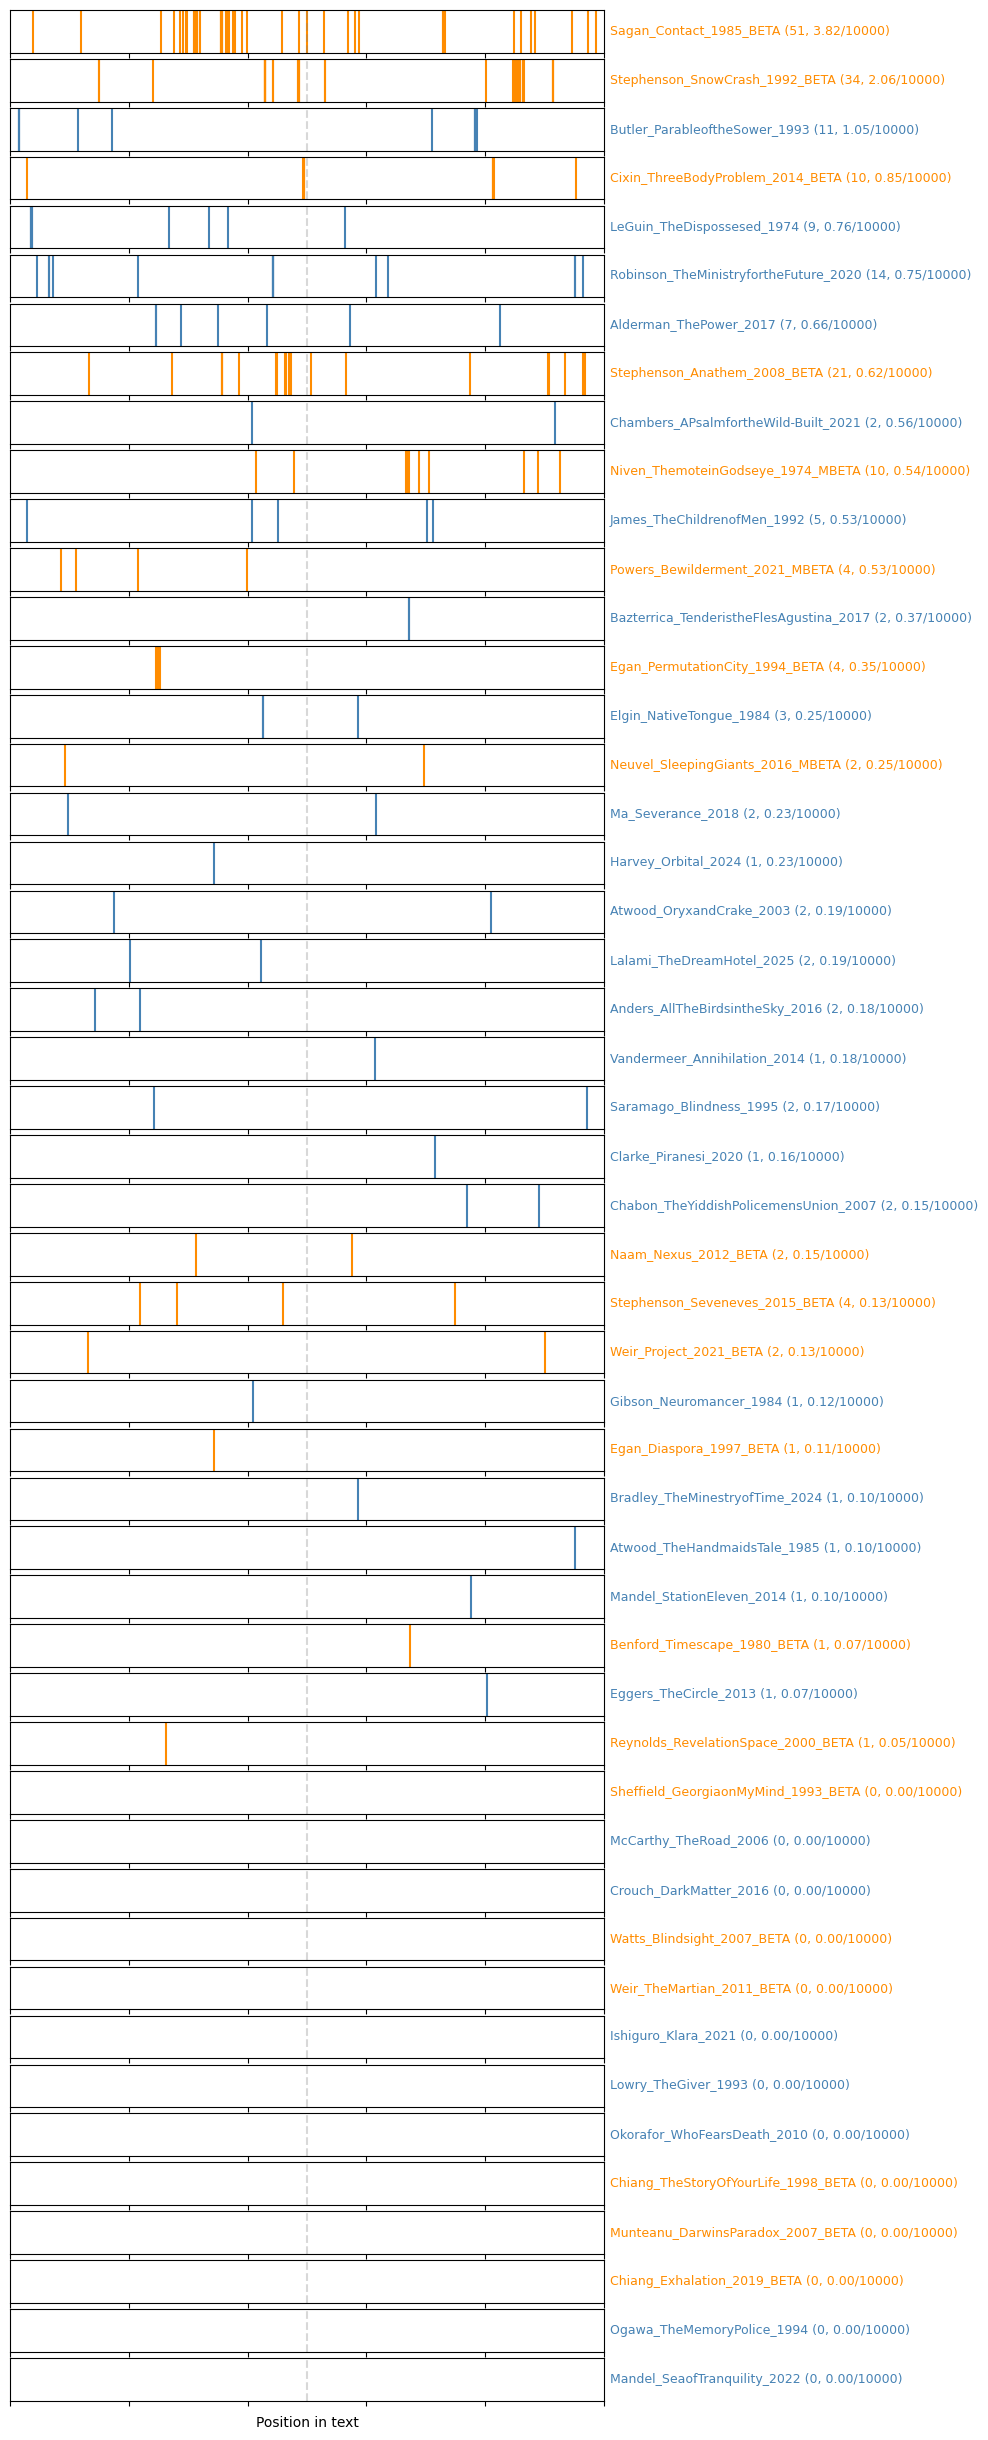

In [31]:
concordance_plot(texts, "religion", word_counts, sort_by="rate", per_n_words=10000)


TODO Idea From Lars: Look for synonims of the Zeta hits, to see if nonbeta authors still use it but maybe in a different, more elaborate, or 'literal' way. 

In [32]:
# concordance_kwic(texts["Egan_Diaspora_1997_BETA"], "ve", width=15)

## PCA from Zeta Analysis

In [33]:
top_zeta_words = zeta_df["Word"].head(100).tolist()
bottom_zeta_words = zeta_df["Word"].tail(100).tolist()

def build_dtm_from_zeta_words(texts, zeta_words):
    dtm = {}

    for title, text in texts.items():
        words = text.lower().split()
        counts = Counter(words)
        
        # Keep only zeta words
        filtered_counts = {word: counts[word] for word in zeta_words}
        dtm[title] = filtered_counts

    return pd.DataFrame.from_dict(dtm, orient="index").fillna(0).astype(int)

In [34]:
dtm_zeta_top = build_dtm_from_zeta_words(texts, top_zeta_words)
dtm_zeta_bottom = build_dtm_from_zeta_words(texts, bottom_zeta_words)

In [35]:
# freq_df_scaled = zscore_normalize(dtm_zeta_bottom)
freq_df_scaled = zscore_normalize(dtm_zeta_top)
pca_df, explained, matrix = run_pca_numpy(freq_df_scaled)
plot_pca(pca_df)


In [36]:
Zpca_df_zoom = filter_outliers(pca_df, z_thresh=0.7)
plot_pca(Zpca_df_zoom, annotate=True)

21 texts excluded as outliers (z_thresh = 0.7):
 - McCarthy_TheRoad_2006
 - Chambers_APsalmfortheWild-Built_2021
 - Benford_Timescape_1980_BETA
 - Egan_Diaspora_1997_BETA
 - Atwood_TheHandmaidsTale_1985
 - Robinson_TheMinistryfortheFuture_2020
 - Weir_TheMartian_2011_BETA
 - Butler_ParableoftheSower_1993
 - Lowry_TheGiver_1993
 - Okorafor_WhoFearsDeath_2010
 - Reynolds_RevelationSpace_2000_BETA
 - Alderman_ThePower_2017
 - Stephenson_Anathem_2008_BETA
 - Bazterrica_TenderistheFlesAgustina_2017
 - James_TheChildrenofMen_1992
 - Weir_Project_2021_BETA
 - Egan_PermutationCity_1994_BETA
 - Cixin_ThreeBodyProblem_2014_BETA
 - Stephenson_Seveneves_2015_BETA
 - Sagan_Contact_1985_BETA
 - Niven_ThemoteinGodseye_1974_MBETA


# 7. Bootstrap Analysis

In [37]:
# def bootstrap_consensus(
#     texts,
#     n_iterations=100,
#     top_n_range=(100, 1000),
#     sample_size=None,
#     distance_metric="cityblock",
#     k_neighbors=3,
#     seed=42,
#     verbose=True,
# ):
#     rng = np.random.default_rng(seed)
#     titles = sorted(texts.keys())
#     consensus = pd.DataFrame(0.0, index=titles, columns=titles)

#     for it in range(n_iterations):
#         top_n = rng.integers(*top_n_range)

#         # Safe equal-length sampling
#         sampled_texts = {}
#         for title, text in texts.items():
#             words = text.lower().split()
#             if sample_size and len(words) > sample_size:
#                 words = rng.choice(words, size=sample_size, replace=False)
#             sampled_texts[title] = " ".join(words) if len(words) > 0 else text

#         # Compute word frequencies and top-N words
#         freqs = word_frequencies_per_text(sampled_texts)
#         top_words = top_n_words_corpus(freqs, n=min(top_n, len(set().union(*[set(c.keys()) for c in freqs.values()]))))

#         # Build frequency matrix, enforce all titles
#         freq_df = frequency_matrix(freqs, top_words)
#         freq_df = freq_df.reindex(titles).fillna(0)

#         # Normalize (safe z-score)
#         freq_df = zscore_normalize(freq_df.replace([np.inf, -np.inf], 0)).fillna(0)

#         # If some text is still entirely zeros (edge case), skip this iteration
#         if (freq_df.sum(axis=1) == 0).any():
#             if verbose:
#                 print(f"⚠️ Iteration {it+1}: Skipped due to empty rows")
#             continue

#         # Compute pairwise distances
#         dist = cdist(freq_df.values, freq_df.values, metric=distance_metric)

#         # Update consensus with top-k neighbors (weighted)
#         for i, a in enumerate(titles):
#             consensus.loc[a, a] += 1
#             ranked = np.argsort(dist[i])
#             for r, j in enumerate(ranked[1:k_neighbors+1]):
#                 b = titles[j]
#                 weight = (k_neighbors - r) / k_neighbors
#                 consensus.loc[a, b] += weight
#                 consensus.loc[b, a] += weight

#         if verbose and (it + 1) % max(1, n_iterations // 10) == 0:
#             print(f"Iteration {it + 1}/{n_iterations} complete")

#     consensus /= consensus.values.max()
#     return consensus


In [38]:
# consensus = bootstrap_consensus(
#     texts,
#     n_iterations=100,
#     top_n_range=(100, 800),
#     sample_size=50000,
#     distance_metric="cityblock"
# )

In [39]:
# fig, ax = plt.subplots(figsize=(10, 8))
# cax = ax.imshow(consensus, cmap="viridis", aspect='auto')
# ax.set_title("Bootstrap Consensus Similarity (Burrows-like Delta)")
# fig.colorbar(cax, ax=ax, label="Similarity")
# ax.set_xlabel("Text")
# ax.set_ylabel("Text")
# plt.tight_layout()
# plt.show()

In [40]:
# def top_consensus_pairs(consensus, threshold=0.7, top_n=20):
#     """
#     Return strongest text pairs above threshold.
#     """
#     pairs = []
#     titles = consensus.index
#     for i, a in enumerate(titles):
#         for j, b in enumerate(titles):
#             if j <= i: 
#                 continue
#             val = consensus.iloc[i, j]
#             if val >= threshold:
#                 pairs.append((a, b, round(val, 3)))
#     pairs.sort(key=lambda x: x[2], reverse=True)
#     return pairs[:top_n]

# # Example
# for a,b,v in top_consensus_pairs(consensus, threshold=0.5):
#     print(f"{a}  ↔  {b}   =  {v}")


In [41]:
# mean_links = consensus.mean(axis=1).sort_values(ascending=False)
# print("most stylistically average / central \n", mean_links.head(10))  # most stylistically average / central
# print("most idiosyncratic / isolated \n", mean_links.tail(10))  # most idiosyncratic / isolated


In [42]:
# import plotly.figure_factory as ff

# def plotly_radial_tree(consensus_matrix, method="average"):
#     from scipy.spatial.distance import squareform
#     from scipy.cluster.hierarchy import linkage
#     dist = 1 - consensus_matrix.values
#     np.fill_diagonal(dist, 0)
#     fig = ff.create_dendrogram(
#         dist, orientation="bottom",
#         labels=consensus_matrix.index.tolist(),
#         linkagefun=lambda x: linkage(squareform(x), method=method)
#     )
#     fig.update_layout(width=900, height=900, title="Bootstrap Consensus Tree (Interactive)")
#     fig.show()


In [43]:
# plotly_radial_tree(consensus, method="average")

In [44]:
# def build_knn_consensus_network(consensus_matrix, k=3):
#     """
#     Build a weighted k-nearest-neighbor consensus network à la Eder (2017).
#     Each text is connected to its k most similar others.
#     """
#     G = nx.Graph()
#     for source in consensus_matrix.index:
#         top_neighbors = (
#             consensus_matrix.loc[source]
#             .drop(source)              # exclude self
#             .sort_values(ascending=False)
#             .head(k)
#         )
#         for target, weight in top_neighbors.items():
#             G.add_edge(source, target, weight=weight)
#     return G

# def plot_consensus_network(G, title="Bootstrap Consensus Network"):
#     plt.figure(figsize=(10, 10))

#     # Convert weights to spring strengths (higher weight = stronger pull)
#     weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
#     pos = nx.spring_layout(G, weight="weight", seed=42, k=1/np.sqrt(len(G.nodes())))

#     # Node sizes proportional to degree
#     degrees = dict(G.degree())
#     sizes = [200 + 800 * (degrees[n]/max(degrees.values())) for n in G.nodes()]

#     # Draw nodes, edges, and labels
#     nx.draw_networkx_edges(G, pos, width=2*weights, alpha=0.4, edge_color="gray")
#     nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="steelblue", alpha=0.9)
#     nx.draw_networkx_labels(G, pos, font_size=7)

#     plt.title(title)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()

# from networkx.algorithms import community

# def plot_modular_consensus_network(G, title="Bootstrap Consensus Network with Communities"):
#     # Detect communities
#     communities = list(community.greedy_modularity_communities(G, weight="weight"))
#     community_map = {}
#     for i, c in enumerate(communities):
#         for node in c:
#             community_map[node] = i

#     # Assign color per community
#     colors = [community_map[n] for n in G.nodes()]
#     pos = nx.spring_layout(G, weight="weight", seed=42, k=1/np.sqrt(len(G.nodes())))

#     plt.figure(figsize=(10, 10))
#     nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.3, edge_color="gray")
#     nx.draw_networkx_nodes(G, pos, node_color=colors, cmap="tab10", node_size=250, alpha=0.9)
#     nx.draw_networkx_labels(G, pos, font_size=7)
#     plt.title(title)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()


In [45]:
# # Build kNN network
# G = build_knn_consensus_network(consensus, k=3)

# # Plot plain version (like Eder Fig. 5)
# plot_consensus_network(G)

# # Plot modular version (colored clusters)
# plot_modular_consensus_network(G)



# 8. Topic Modelling

In [46]:
# import os
# import re
# import unicodedata
# from collections import Counter
# from nltk.corpus import stopwords
# import nltk

# # Download NLTK stopwords if not already downloaded
# nltk.download("stopwords", quiet=True)

# def preprocess_texts_for_topic_modeling(corpus_path, selected_files=None, min_name_freq=5):
#     """
#     Clean and preprocess texts: normalize, remove stopwords, remove probable names.

#     Args:
#         corpus_path (str): Folder containing .txt files
#         selected_files (list): Optional list of filenames (without .txt) to include
#         min_name_freq (int): Minimum frequency for capitalized words to be considered names

#     Returns:
#         dict: {title: cleaned_text} ready for topic modeling
#     """
#     stopword_set = set(stopwords.words("english"))
#     raw_texts = {}
    
#     # Step 1: Load raw texts
#     for filename in os.listdir(corpus_path):
#         if filename.endswith(".txt"):
#             title = os.path.splitext(filename)[0]
#             if selected_files and title not in selected_files:
#                 continue
#             with open(os.path.join(corpus_path, filename), 'r', encoding='utf-8') as f:
#                 raw_texts[title] = f.read()
    
#     # Step 2: Find probable names (capitalized, frequent)
#     cap_counter = Counter()
#     for text in raw_texts.values():
#         words = re.findall(r'\b[A-Z][a-z]+\b', text)
#         cap_counter.update(words)
    
#     auto_names = {w.lower() for w, c in cap_counter.items() if c >= min_name_freq}
    
#     # Step 3: Clean texts
#     cleaned_texts = {}
#     for title, text in raw_texts.items():
#         # Unicode normalization
#         text = unicodedata.normalize("NFKC", text)

#         # Standardize quotes and dashes
#         text = text.replace("“", '"').replace("”", '"')
#         text = text.replace("‘", "'").replace("’", "'")
#         text = text.replace("–", "-").replace("—", "-")

#         # Remove tabs, non-breaking spaces, form feeds
#         text = text.replace("\t", " ").replace("\xa0", " ").replace("\f", " ")

#         # Lowercase and tokenize
#         text = re.sub(r"\s+", " ", text).lower()
#         tokens = re.findall(r"\b[a-z']{2,}\b", text)

#         # Remove stopwords and names
#         tokens = [t for t in tokens if t not in stopword_set and t not in auto_names]

#         # Recombine
#         cleaned_texts[title] = " ".join(tokens)

#     return cleaned_texts

# corpus_path = "/Users/floorstikkelbroeck/Desktop/MA_CompLit_Thesis/corpus_thesis"
# texts = preprocess_texts_for_topic_modeling(corpus_path)


In [47]:
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.decomposition import LatentDirichletAllocation
# import pandas as pd
# import numpy as np

# def run_topic_model(
#     texts,
#     n_topics=8,
#     max_features=5000,
#     min_df=3,
#     max_df=0.9,
#     random_state=42,
#     n_top_words=10
# ):
#     """
#     Perform LDA topic modeling on the given corpus.

#     Args:
#         texts (dict): {title: text}
#         n_topics (int): number of latent topics
#         max_features (int): max vocabulary size
#         min_df (int): min number of texts a word must appear in
#         max_df (float): max proportion of texts a word can appear in
#         n_top_words (int): number of top words to display per topic

#     Returns:
#         lda (model): trained LDA model
#         dtm (DataFrame): document–term matrix
#         topic_word_df (DataFrame): top words per topic
#         doc_topic_df (DataFrame): topic proportions per document
#     """
#     titles = list(texts.keys())
#     corpus = list(texts.values())

#     # Vectorize texts (bag-of-words)
#     vectorizer = CountVectorizer(
#         stop_words='english',
#         max_df=max_df,
#         min_df=min_df,
#         max_features=max_features
#     )
#     X = vectorizer.fit_transform(corpus)

#     # Train LDA
#     lda = LatentDirichletAllocation(
#         n_components=n_topics,
#         random_state=random_state,
#         learning_method='batch'
#     ).fit(X)

#     # Get vocabulary
#     words = np.array(vectorizer.get_feature_names_out())

#     # Top words per topic
#     topic_word_df = pd.DataFrame({
#         f"Topic {i+1}": [words[j] for j in lda.components_[i].argsort()[:-n_top_words-1:-1]]
#         for i in range(n_topics)
#     })

#     # Topic proportions per document
#     doc_topic = lda.transform(X)
#     doc_topic_df = pd.DataFrame(doc_topic, index=titles, columns=[f"Topic {i+1}" for i in range(n_topics)])

#     return lda, pd.DataFrame(X.toarray(), columns=words, index=titles), topic_word_df, doc_topic_df

# lda_model, dtm, topics, doc_topics = run_topic_model(texts, n_topics=10)


In [48]:
# topics
# # doc_topics


In [49]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.imshow(doc_topics, cmap="YlGnBu")
# plt.title("Topic proportions per text")
# plt.xlabel("Topics")
# plt.ylabel("Texts")
# plt.show()


### New Trial

In [50]:
# import os
# import re
# import unicodedata
# from collections import Counter
# import nltk
# from nltk.corpus import stopwords

# import spacy
# from gensim.models.phrases import Phrases, Phraser
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.decomposition import LatentDirichletAllocation
# import pandas as pd
# import numpy as np

# # Download stopwords
# nltk.download("stopwords", quiet=True)

# # Load spaCy
# nlp = spacy.load("en_core_web_sm")

# # -------------------------------
# # 1. FICTION-SPECIFIC STOPWORDS
# # -------------------------------

# fiction_stopwords = {
#     # gesture verbs
#     "nodded","nodding","looked","looking","glanced","glancing","stared",
#     "smiled","smiling","frowned","whispered","whispering",
#     "gestured","shrugged","sighed","laughed","crying","cried",

#     # speech verbs
#     "said","saying","ask","asked","asking","reply","replied","replying",
#     "answer","answered","shouted","yelled","murmured","muttered",

#     # filler verbs + narrative glue
#     "seemed","seem","felt","feel","feeling","appeared","appearing",
#     "got","getting","went","go","going","came","come","coming",
#     "turned","turning","walked","walking","stood","standing",

#     # generic characters
#     "mother","father","husband","wife","man","woman","boy","girl",
# }

# trivial_nouns = {
#     "room","hallway","bedroom","door","window","hand","face","father","mother",
#     "coat","hat","knife","rifle","weapon","plate","cart","blanket","tent",
#     "campus","neighborhood","street","town","city","country","environment",
#     "file","folder","photo","camera","account","role","symbol","color"
# }


# stopword_set = set(stopwords.words("english")) | fiction_stopwords


# # -------------------------------
# # 2. PREPROCESSING PIPELINE
# # -------------------------------

# def preprocess_corpus_for_topics(corpus_path, min_name_freq=5):
#     raw_texts = {}
#     for filename in os.listdir(corpus_path):
#         if filename.endswith(".txt"):
#             title = os.path.splitext(filename)[0]
#             with open(os.path.join(corpus_path, filename), "r", encoding="utf-8") as f:
#                 raw_texts[title] = f.read()

#     # Step 2: Detect probable names
#     cap_counter = Counter()
#     for text in raw_texts.values():
#         words = re.findall(r"\b[A-Z][a-z]+\b", text)
#         cap_counter.update(words)
#     auto_names = {w.lower() for w, c in cap_counter.items() if c >= min_name_freq}

#     # Step 3: Normalize, tokenize, remove stopwords/names
#     cleaned = {}
#     for title, text in raw_texts.items():

#         text = unicodedata.normalize("NFKC", text)
#         text = (text.replace("“", '"').replace("”", '"')
#                     .replace("‘", "'").replace("’", "'")
#                     .replace("–", "-").replace("—", "-"))
#         text = text.replace("\xa0", " ").replace("\t", " ").replace("\f", " ")
#         text = text.lower()

#         tokens = re.findall(r"\b[a-z']{2,}\b", text)

#         tokens = [t for t in tokens 
#                   if t not in stopword_set 
#                   and t not in auto_names 
#                   and t not in trivial_nouns]

#         cleaned[title] = tokens

#     # Step 4: Lemmatize into nouns + noun phrases
#     def extract_noun_phrases(text):
#         doc = nlp(text)
#         phrases = []
#         for chunk in doc.noun_chunks:
#             phrase = "_".join([t.lemma_ for t in chunk if t.pos_ == "NOUN"])
#             if phrase and len(phrase) > 3:
#                 phrases.append(phrase)
#         return phrases

#     noun_cleaned = {}
#     for title, tokens in cleaned.items():
#         doc = nlp(" ".join(tokens))
#         nouns = [t.lemma_ for t in doc 
#                  if t.pos_ in {"NOUN","PROPN"} and len(t.lemma_) > 2]

#         # Extract noun phrases
#         noun_phrases = extract_noun_phrases(" ".join(nouns))

#         # Combine nouns + noun_phrases
#         noun_cleaned[title] = nouns + noun_phrases

#     # Step 5: Bigrams and trigrams
#     sentences = list(noun_cleaned.values())

#     bigram = Phrases(sentences, min_count=3, threshold=5)
#     trigram = Phrases(bigram[sentences], min_count=3, threshold=5)

#     bigram_mod = Phraser(bigram)
#     trigram_mod = Phraser(trigram)

#     final_texts = {
#         title: " ".join(trigram_mod[bigram_mod[tokens]])
#         for title, tokens in noun_cleaned.items()
#     }

#     return final_texts


# # -------------------------------
# # 3. TOPIC MODELLING PIPELINE
# # -------------------------------

# def run_lda_topics(text_dict, n_topics=6, max_features=6000, min_df=5):
#     titles = list(text_dict.keys())
#     corpus = list(text_dict.values())

#     vectorizer = CountVectorizer(
#         max_df=0.85,
#         min_df=min_df,
#         max_features=max_features,
#         token_pattern=r"(?u)\b[A-Za-z_]+\b"    # allow bigram/trigram tokens
#     )

#     X = vectorizer.fit_transform(corpus)
#     words = np.array(vectorizer.get_feature_names_out())

#     lda = LatentDirichletAllocation(
#         n_components=n_topics,
#         random_state=42,
#         learning_method="batch"
#     ).fit(X)

#     # Top words
#     topic_words = {
#         f"Topic {i+1}": [words[j] for j in lda.components_[i].argsort()[-10:][::-1]]
#         for i in range(n_topics)
#     }
#     topic_word_df = pd.DataFrame(topic_words)

#     # Per-document topic distribution
#     doc_topics = lda.transform(X)
#     doc_topic_df = pd.DataFrame(doc_topics, index=titles, columns=[f"Topic {i+1}" for i in range(n_topics)])

#     return lda, topic_word_df, doc_topic_df


# # -------------------------------
# # 4. RUN EVERYTHING
# # -------------------------------

# corpus_path = "/Users/floorstikkelbroeck/Desktop/MA_CompLit_Thesis/corpus_thesis"

# texts = preprocess_corpus_for_topics(corpus_path)
# lda_model, topics, doc_topics = run_lda_topics(texts, n_topics=6, min_df=12)


# topics


In [51]:
# import bertopic
# bertopic.__version__


In [52]:
# from bertopic import BERTopic
# from sentence_transformers import SentenceTransformer

# embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# topic_model = BERTopic(
#     embedding_model=embedding_model,
#     umap_model=None,        # disable UMAP
#     hdbscan_model=None,     # disable HDBSCAN (uses k-means under the hood)
#     calculate_probabilities=False,
#     verbose=True
# )

# corpus = list(texts.values())
# emb = embedding_model.encode(corpus, batch_size=4, show_progress_bar=True)

# topics, probs = topic_model.fit_transform(corpus, emb)

# topic_model.get_topic_info()


In [53]:
# topic_model.get_topic(0)

# doc_topics = topic_model.topics_
# pd.DataFrame({"title": titles, "topic": doc_topics})


In [54]:
# topic_model.visualize_topics()
# topic_model.visualize_hierarchy()
# topic_model.visualize_barchart()


In [55]:
# corpus = pd.DataFrame(texts.values(), columns=["text"])
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Remove stopwords and constrain dimensionality by requiring a term to show up in at least 5 documents but not more than 75% of documents
# tfidf_vectorizer = TfidfVectorizer(
#     stop_words='english',
#     max_df=0.75,
#     min_df=5,
#     token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"   # <— fix!
# )

# # Tokenize and perform the TF-IDF calculation for before LDA 
# doc_term_matrix = tfidf_vectorizer.fit_transform(corpus["text"])

# from sklearn.decomposition import LatentDirichletAllocation
# num_topics = 8
# lda_model = LatentDirichletAllocation(n_components=num_topics)

# #Train the LDA model and get the document topic distributions
# doc_topic_matrix = lda_model.fit_transform(doc_term_matrix)

# col_names = [f"Topic {i+1}" for i in range(num_topics)]

# # Create a DataFrame with document-topic distributions
# doc_topic_df = pd.DataFrame(doc_topic_matrix, columns=col_names)

# #Display the top 10 words for each topic
# num_words = 10

# for topic, words in enumerate(lda_model.components_):
#     top_words_indices = words.argsort()[-num_words:][::-1]
#     top_words = [tfidf_vectorizer.get_feature_names_out()[i] for i in top_words_indices]
#     print(f"Topic {topic + 1}: {', '.join(top_words)}")


In [56]:
# =============================================================
# FINAL CLEAN, SAFE, SINGLE-CELL TOPIC MODELLING PIPELINE
# =============================================================

import re
import spacy
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# -------------------------------------------------------------
# 1. DETECT CHARACTER NAMES (no NER needed, avoids crashes)
# -------------------------------------------------------------
character_names = Counter()

for text in texts.values():
    # Find repeated capitalized words (names)
    caps = re.findall(r"\b[A-Z][a-z]{2,}\b", text)
    character_names.update(caps)

# Keep names that appear at least 5 times across the corpus
character_names = {name.lower() for name, count in character_names.items() if count >= 5}


# -------------------------------------------------------------
# 2. LOAD SPACY (parser + NER disabled for safety)
# -------------------------------------------------------------
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
nlp.max_length = 2_000_000     # safe for full novels


# -------------------------------------------------------------
# 3. PREPROCESSING: nouns only + remove detected character names
# -------------------------------------------------------------
def preprocess(text):
    doc = nlp(text)
    nouns = [
        token.lemma_.lower()
        for token in doc
        if token.pos_ == "NOUN"
        and token.lemma_.lower() not in character_names
    ]
    return " ".join(nouns)


# -------------------------------------------------------------
# 4. APPLY PREPROCESSING (single-threaded for stability)
# -------------------------------------------------------------
clean_texts = [preprocess(text) for text in texts.values()]

corpus = pd.DataFrame({"clean": clean_texts})


# -------------------------------------------------------------
# 5. VECTORIZATION (CountVectorizer → best for LDA)
# -------------------------------------------------------------
vectorizer = CountVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
    max_df=0.7,
    min_df=5,
    max_features=7000
)

X = vectorizer.fit_transform(corpus["clean"])
vocab = vectorizer.get_feature_names_out()


# -------------------------------------------------------------
# 6. LDA TOPIC MODELLING
# -------------------------------------------------------------
n_topics = 10

lda = LatentDirichletAllocation(
    n_components=n_topics,
)

doc_topic_matrix = lda.fit_transform(X)


# -------------------------------------------------------------
# 7. DISPLAY TOP WORDS PER TOPIC
# -------------------------------------------------------------
n_words = 12

for topic_idx, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-n_words:][::-1]
    words = vocab[top_idx]
    print(f"\n=== TOPIC {topic_idx+1} ===")
    print(", ".join(words))


KeyboardInterrupt: 

In [ ]:
doc_topic_matrix_df = pd.DataFrame(
    doc_topic_matrix,
    index=texts.keys(),
    columns=[f"Topic {i+1}" for i in range(n_topics)]
)

titles = list(doc_topic_matrix_df.index)

# Split BETA vs non-BETA
beta_mask = doc_topic_matrix_df.index.str.contains("BETA", case=False)
beta_df = doc_topic_matrix_df[beta_mask].sort_index()
non_beta_df = doc_topic_matrix_df[~beta_mask].sort_index()

sorted_df = pd.concat([beta_df, non_beta_df], axis=0)

# --- Convert values to percentages for annotation ---
percent_labels = (sorted_df * 100).round(1).astype(str) + "%"

plt.figure(figsize=(4.5, 12))

sns.heatmap(
    sorted_df,
    cmap="rocket",
    linewidths=0.5,
    linecolor="gray",
    annot=percent_labels,         # <--- percent text inside cells
    fmt="",                       # <--- we already formatted the strings
    cbar_kws={"label": "Topic weight"},
    annot_kws={"fontsize": 6}     # <--- small font so it fits
)

plt.tight_layout()
plt.show()


## Topic Coherence Analysis

In [ ]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

tokenized = [doc.split() for doc in corpus["clean"]]
dictionary = Dictionary(tokenized)
corpus_gensim = [dictionary.doc2bow(tokens) for tokens in tokenized]

coherence_scores = []
topic_nums = range(2, 20)   # test 2–10 topics

for k in topic_nums:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        random_state=42
    )
    lda_k.fit(X)

    # Extract top words per topic
    top_words = []
    for i in range(k):
        top_idx = lda_k.components_[i].argsort()[-10:]
        top_words.append([vocab[j] for j in top_idx])

    # Compute coherence
    cm = CoherenceModel(
        topics=top_words,
        texts=tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    coherence_scores.append(cm.get_coherence())

coherence_scores



In [ ]:
import matplotlib.pyplot as plt

plt.plot(topic_nums, coherence_scores, marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence score (Cv)")
plt.title("Topic Coherence vs Number of Topics")
plt.show()


The Answer is that #three topics# work best for this analysis. 

In [ ]:
from gensim.models import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
import numpy as np

min_df_list = [2,3,4,5,6]
max_df_list = [0.70,0.75,0.80,0.85,0.90]

results = []

texts_tokenized = [doc.split() for doc in corpus["clean"]]

for min_df in min_df_list:
    for max_df in max_df_list:

        vectorizer = CountVectorizer(
            token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
            stop_words="english",
            min_df=min_df,
            max_df=max_df
        )

        try:
            X = vectorizer.fit_transform(corpus["clean"])
            vocab = vectorizer.get_feature_names_out()

            lda = LatentDirichletAllocation(
                n_components=3,   # or 4
                random_state=42
            ).fit(X)

            # Convert to Gensim format
            dictionary = Dictionary(texts_tokenized)
            corpus_gensim = [dictionary.doc2bow(text) for text in texts_tokenized]

            cm = CoherenceModel(
                topics=[ [vocab[i] for i in topic.argsort()[-20:]] for topic in lda.components_ ],
                texts=texts_tokenized,
                dictionary=dictionary,
                coherence="c_v"
            )
            coherence = cm.get_coherence()

            results.append((min_df, max_df, coherence))

        except:
            continue

best = max(results, key=lambda x: x[2])
best
